<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
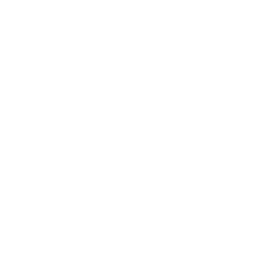
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ανάλυση Τάσης EWMA Ποσοστού Σφαλμάτων Φαρμακευτικής Αγωγής</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Υγειονομική Περίθαλψη / Ασφάλεια Ασθενών &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Αυτή η ανάλυση παρακολουθεί το εβδομαδιαίο ποσοστό σφαλμάτων φαρμακευτικής αγωγής σε μια μονάδα εντατικής θεραπείας (ΜΕΘ) νοσοκομείου χρησιμοποιώντας ένα **διάγραμμα ελέγχου εκθετικά σταθμισμένου κινητού μέσου όρου (EWMA)** από την PROC MACONTROL. Η ΜΕΘ έθεσε σε λειτουργία ένα νέο ηλεκτρονικό σύστημα καταγραφής χορήγησης φαρμάκων (eMAR) την εβδομάδα 51 του παραθύρου παρατήρησης. Οι ομάδες ασφάλειας ασθενών χρειάζονται μια μέθοδο έγκαιρης προειδοποίησης που επισημαίνει γρήγορα μια διατηρούμενη αύξηση σφαλμάτων, πριν συσσωρευτεί το ένα τέταρτο των αναφορών βλάβης.

Το διάγραμμα EWMA με βάρος εξομάλυνσης **lambda = 0,3** κατασκευάζεται σε δύο φάσεις. Τα όρια ελέγχου καθιερώνονται πρώτα από τη σταθερή περίοδο βάσης πριν τη μετάβαση (εβδομάδες 1-50), και στη συνέχεια η πλήρης σειρά 100 εβδομάδων παρακολουθείται έναντι αυτών των σταθερών ορίων. Το διάγραμμα παραμένει εντός ελέγχου καθ' όλη τη διάρκεια της περιόδου βάσης και σηματοδοτεί μια κατάσταση εκτός ελέγχου την **πρώτη εβδομάδα μετά την έναρξη λειτουργίας**, επιβεβαιώνοντας ότι η μετάβαση στο eMAR συνέπεσε με μια πραγματική, διατηρούμενη μεταβολή στο ποσοστό σφαλμάτων και όχι με απλό θόρυβο από εβδομάδα σε εβδομάδα.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Εβδομαδιαίο ποσοστό σφαλμάτων φαρμακευτικής αγωγής ανά 1.000 χορηγήσεις για μία ΜΕΘ, 100 συνεχόμενες εβδομάδες | 100 |

Μία μόνο ΜΕΘ παρακολουθείται εβδομαδιαία. Κάθε εγγραφή περιέχει τον αριθμό εβδομάδας, το ποσοστό σφαλμάτων ανά 1.000 χορηγήσεις, τον όγκο χορηγήσεων και τον παράγωγο αριθμό σφαλμάτων. Μια τεκμηριωμένη αλλαγή διαδικασίας (έναρξη λειτουργίας eMAR) συμβαίνει την εβδομάδα 51, μετατοπίζοντας τον υποκείμενο μέσο όρο ποσοστού σφαλμάτων προς τα πάνω κατά περίπου 1,6 ανά 1.000.


---

In [1]:
/* --------------------------------------------------------
   Δημιουργια εβδομαδιαιων δεδομενων σφαλματων φαρμακευτικης
   αγωγης ΜΕΘ. 100 συνεχομενες εβδομαδες για μια ΜΕΘ.
   Ενα νεο συστημα eMAR τιθεται σε λειτουργια την εβδομαδα 51,
   αυξανοντας τον υποκειμενο μεσο ορο ποσοστου σφαλματων απο
   ~3,5 σε ~5,1 ανα 1.000.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.icu_errors;
    CALL streaminit(42);
    LENGTH unit_name $12 phase $40;
    unit_name = 'ΜΕΘ';
    base_rate  = 3.5;   /* μεσο ποσοστο προ-μεταβασης / 1.000 */
    unit_sigma = 0.45;  /* κοινης-αιτιας θορυβος απο εβδομαδα σε εβδομαδα */
    ΕΠΑΝΑΛΗΨΗ week_num = 1 ΕΩΣ 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        ΕΑΝ administrations < 300 ΤΟΤΕ administrations = 300;
        /* η μεταβαση eMAR μετατοπιζει τον μεσο ορο προς τα πανω μετα την εβδομαδα 50 */
        ΕΑΝ week_num > 50 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            phase = 'ΜΕΤΑ-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            phase = 'ΓΡΑΜΜΗ ΒΑΣΗΣ';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        ΤΕΛΟΣ;
        ΕΑΝ error_rate_per_1k < 0 ΤΟΤΕ error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ base_rate unit_sigma;
    ΜΟΡΦΗ week_start_date date9.;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                  Ποσοστό Σφαλμάτων ΜΕΘ: Γραμμή Βάσης έναντι Μετά-eMAR                                  

                                                  The MEANS Procedure

                  Analysis Variable : error_rate_per_1k Ποσοστό Σφαλμάτων ανά 1.000

        Φάση                             N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------
        ΓΡΑΜΜΗ ΒΑΣΗΣ                        50           3.50           0.48           2.55           4.71
        ΜΕΤΑ-eMAR                           50           5.11           0.44           3.69           5.96
        --------------------------------------------------------------------------------------------------

                           Analysis Variable : error_count Αριθμός Σφαλμάτων

        Φάση                             N Obs           Mean        Std Dev        Minimum        Maximum
 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


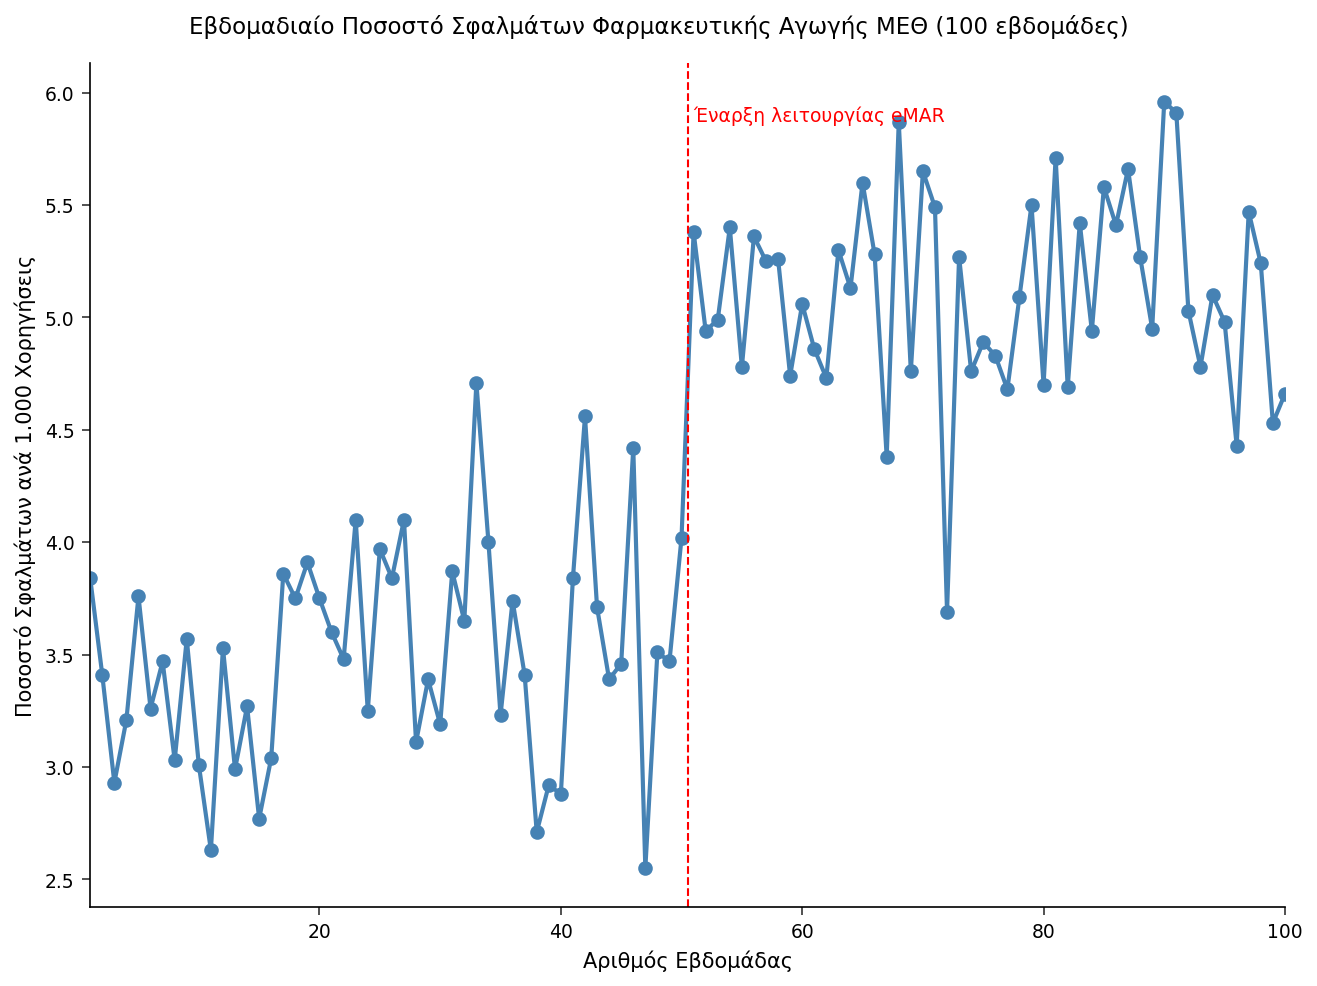

In [2]:
/* --------------------------------------------------------
   Συγκριση του ποσοστου σφαλματων πριν και μετα την εναρξη
   λειτουργιας eMAR, και σχεδιαση της εβδομαδιαιας ταση.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.icu_errors n mean std MIN MAX maxdec=2;
    ΚΛΑΣΗ phase;
    ΜΕΤΑΒΛΗΤΗ error_rate_per_1k error_count administrations;
    ΕΤΙΚΕΤΑ phase             = 'Φάση'
          error_rate_per_1k  = 'Ποσοστό Σφαλμάτων ανά 1.000'
          error_count        = 'Αριθμός Σφαλμάτων'
          administrations    = 'Χορηγήσεις';
    TITLE 'Ποσοστό Σφαλμάτων ΜΕΘ: Γραμμή Βάσης έναντι Μετά-eMAR';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ΕΤΙΚΕΤΑ='Έναρξη λειτουργίας eMAR';
    XAXIS ΕΤΙΚΕΤΑ='Αριθμός Εβδομάδας';
    YAXIS ΕΤΙΚΕΤΑ='Ποσοστό Σφαλμάτων ανά 1.000 Χορηγήσεις';
    TITLE 'Εβδομαδιαίο Ποσοστό Σφαλμάτων Φαρμακευτικής Αγωγής ΜΕΘ (100 εβδομάδες)';
ΕΚΤΕΛΕΣΗ;


---

In [3]:
/* --------------------------------------------------------
   Φαση I: καθιερωση οριων ελεγχου EWMA απο τη σταθερη περιοδο
   βασης προ-μεταβασης (εβδομαδες 1-50). Αυτα τα σταθερα ορια
   γινονται το μετρο για ολη την περιοδο παρακολουθησης.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.icu_errors(ΟΠΟΥ=(week_num <= 50)) NOPRINT;
    ΜΕΤΑΒΛΗΤΗ error_rate_per_1k;
    ΕΞΟΔΟΣ out=work.baseline_stats mean=base_mean std=base_std;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.icu_limits;
    ΟΡΙΣΜΟΣ work.baseline_stats;
    LENGTH _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* κεντρικη γραμμη βασης */
    _STDDEV_ = base_std;    /* κοινης-αιτιας σιγμα βασης */
    _LIMITN_ = 1;
    ΚΡΑΤΗΣΗ _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.icu_limits noobs;
    TITLE 'Είσοδοι Ορίων Ελέγχου Φάσης I (βάση εβδομάδες 1-50)';
ΕΚΤΕΛΕΣΗ;


                                  Είσοδοι Ορίων Ελέγχου Φάσης I (βάση εβδομάδες 1-50)                                   

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                  Είσοδοι Ορίων Ελέγχου Φάσης I (βάση εβδομάδες 1-50)                                   


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/f105b3fa-177f-47c5-8531-5e209842b6e5/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


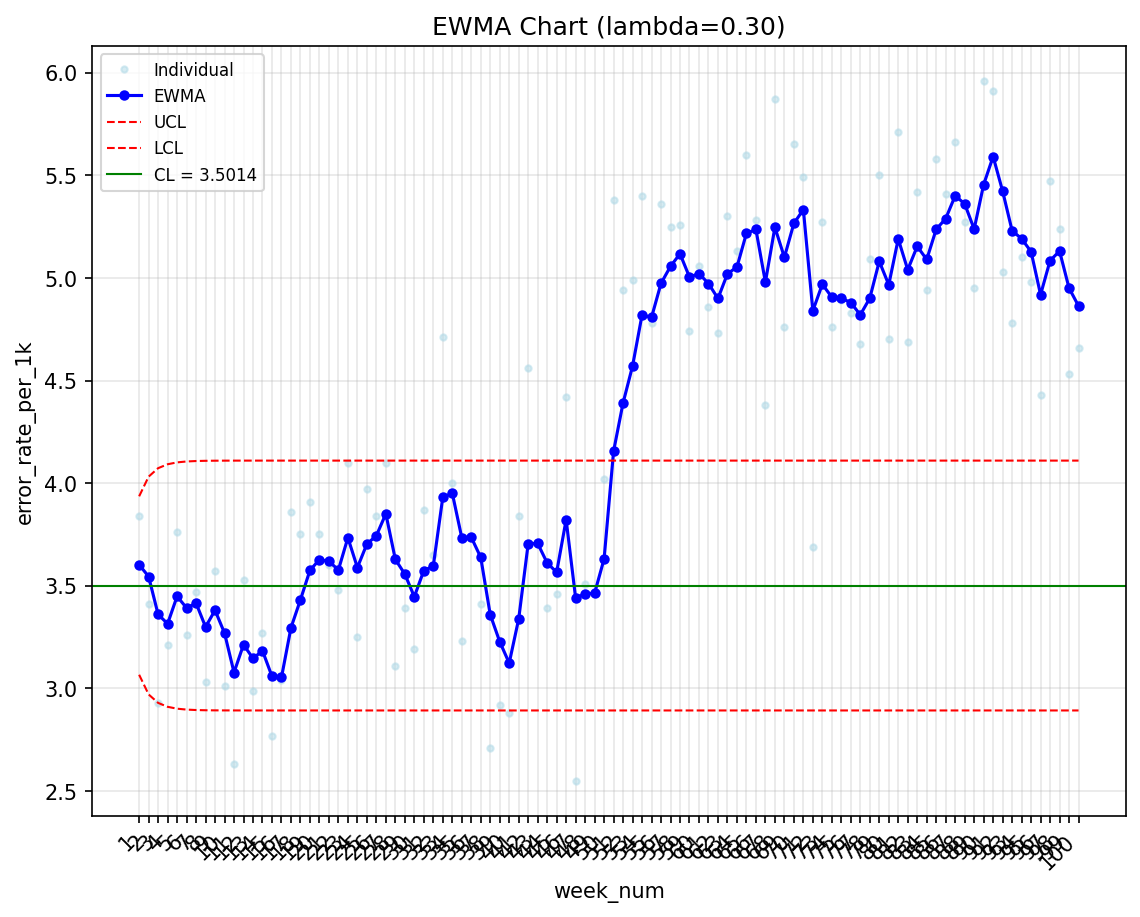

In [4]:
/* --------------------------------------------------------
   Φαση II: παρακολουθηση ολης της σειρας 100 εβδομαδων εναντι
   των σταθερων οριων βασης. lambda=0,3 δινει ανταποκρισιμη
   ανιχνευση καταλληλη για επιτηρηση ασφαλειας ασθενων.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ macontrol ΔΕΔΟΜΕΝΑ=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        ΒΑΡΟΣ    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ΕΤΙΚΕΤΑ error_rate_per_1k =
          'Σφάλματα Φαρμακευτικής Αγωγής ανά 1.000 Χορηγήσεις';
    TITLE 'Διάγραμμα EWMA: Ποσοστό Σφαλμάτων Φαρμακευτικής Αγωγής ΜΕΘ (lambda=0,3)';
ΕΚΤΕΛΕΣΗ;


---

In [5]:
/* --------------------------------------------------------
   Εντοπισμος καθε εβδομαδας οπου το EWMA παραβιαζει τα ορια
   βασης και αναφορα ποτε το διαγραμμα σηματοδοτει για πρωτη φορα.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.signals;
    ΟΡΙΣΜΟΣ work.icu_table;
    ΟΠΟΥ _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SQL;
    ΕΠΙΛΟΓΗ count(*)        AS n_signals          ΕΤΙΚΕΤΑ='Εβδομάδες Σήματος',
           MIN(week_num)    AS first_signal_week  ΕΤΙΚΕΤΑ='Πρώτη Εβδομάδα Σήματος',
           MAX(_EWMA_)      AS peak_ewma ΜΟΡΦΗ=6.3 ΕΤΙΚΕΤΑ='Μέγιστο EWMA'
    FROM work.signals;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.signals(obs=8);
    ΜΕΤΑΒΛΗΤΗ week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    ΕΤΙΚΕΤΑ week_num           = 'Εβδομάδα'
          error_rate_per_1k  = 'Ποσοστό Σφαλμάτων ανά 1.000'
          _EWMA_             = 'EWMA'
          _UCLE_             = 'Άνω Όριο Ελέγχου'
          _EXLIM_            = 'Εκτός Ορίων';
    TITLE 'Πρώτα Σήματα EWMA Εκτός Ελέγχου';
ΕΚΤΕΛΕΣΗ;


                                  Είσοδοι Ορίων Ελέγχου Φάσης I (βάση εβδομάδες 1-50)                                   

                Εβδομάδες Σήματος                      Πρώτη Εβδομάδα Σήματος         Μέγιστο EWMA
---------------------------------  ------------------------------------------  -------------------
                               50                                        51.0                5.591
                                            Πρώτα Σήματα EWMA Εκτός Ελέγχου                                             

  Obs          Εβδομάδα      EWMA                Άνω Όριο Ελέγχου            Εκτός Ορίων
    1                51  4.155551                         4.10998                      1
    2                52  4.390886                         4.10998                      1
    3                53   4.57062                         4.10998                      1
    4                54  4.819434                         4.10998                      1
    5         


NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Ερμηνεία

Η ανάλυση EWMA δύο φάσεων διαχωρίζει καθαρά τη συνήθη διακύμανση από εβδομάδα σε εβδομάδα από την πραγματική αλλαγή διαδικασίας κατά την έναρξη λειτουργίας του eMAR.

**Βάση (εβδομάδες 1-50).** Η PROC MEANS αναφέρει μέσο ποσοστό σφαλμάτων βάσης **3,50 ανά 1.000 χορηγήσεις** (τυπική απόκλιση 0,48), έναντι μέσου όρου μετα-μετάβασης **5,11** (τυπική απόκλιση 0,44) -- μια διατηρούμενη ανοδική μετατόπιση περίπου **1,6 σφαλμάτων ανά 1.000**. Ο όγκος χορηγήσεων είναι συγκρίσιμος στις δύο φάσεις (795 έναντι 790 ανά εβδομάδα), οπότε η αλλαγή αντικατοπτρίζει το *ποσοστό* σφαλμάτων, όχι μια μεταβολή στον φόρτο εργασίας.

**Όρια ελέγχου.** Τα όρια είναι σταθερά μόνο από τη βάση: κεντρική γραμμή **3,5014**, σίγμα βάσης **0,4829**. Με βάρος εξομάλυνσης lambda = 0,3 και όρια 3-σίγμα, το άνω όριο EWMA σταθεροποιείται στην ασυμπτωτική του τιμή περίπου **4,11**. Καθ' όλη τη διάρκεια των εβδομάδων 1-50 η στατιστική EWMA παραμένει εντός αυτών των ορίων -- η βάση παράγει **μηδέν ψευδείς συναγερμούς**, επιβεβαιώνοντας ότι το διάγραμμα δεν είναι υπερβολικά ευαίσθητο.

**Ανίχνευση.** Το διάγραμμα σηματοδοτεί εκτός ελέγχου την **πρώτη κιόλας εβδομάδα μετά την έναρξη λειτουργίας (εβδομάδα 51)**, όπου το EWMA φτάνει **4,156**, ακριβώς πάνω από το όριο 4,11. Από εκείνο το σημείο η στατιστική ανεβαίνει σταθερά και παραμένει πάνω από το άνω όριο για ολόκληρη την περίοδο μετα-μετάβασης: **όλες οι 50 εβδομάδες μετα-μετάβασης (51-100) σηματοδοτούν**, και το EWMA κορυφώνεται στο **5,591** γύρω στην εβδομάδα 91. Η ανταπόκριση του lambda = 0,3 σημαίνει ότι η επιδείνωση επισημαίνεται αμέσως αντί μετά από αρκετές εβδομάδες συσσώρευσης.

**Ενέργεια.** Μια διατηρούμενη παραβίαση EWMA που ξεκινά την εβδομάδα μιας έναρξης λειτουργίας eMAR αποτελεί ισχυρή ένδειξη ότι το νέο σύστημα -- και όχι η τύχη -- προκάλεσε την αύξηση. Η επιτροπή ασφάλειας ασθενών θα πρέπει να αντιμετωπίσει την εβδομάδα 51 ως το σημείο αλλαγής, να ελέγξει τις ροές εργασίας παραγγελίας φαρμάκων και παράκαμψης του eMAR που εισήχθησαν εκείνη την εβδομάδα, και να διατηρήσει το διάγραμμα σε λειτουργία έναντι των αρχικών ορίων βάσης μέχρι το EWMA να επιστρέψει κάτω από το 4,11. Τα εξαγόμενα `icu_ewma_signals.csv` (50 εβδομάδες σήματος) και `icu_ewma_table.csv` παρέχουν το τεκμηριωμένο ίχνος αποδεικτικών στοιχείων SPC για τη συνεχή ετοιμότητα ελέγχου της Joint Commission.


---

In [6]:
/* --------------------------------------------------------
   Εξαγωγη του πινακα EWMA και της λιστας σηματων για την
   τεκμηριωση συνεχους ετοιμοτητας της Joint Commission.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>